# Interpolación de Chebyshev

Los polinomios de Chebyshev $\{T_{n}(x)\}$ son ortogonales en $(−1, 1)$ con respecto a la función de peso $w(x) = (1 − x^{2})^{-1/2}$. Se utilizan para minimizar el error de aproximación y se emplean para resolver dos problemas de este tipo:

* una ubicación óptima de los puntos de interpolación para minimizar el error en la interpolación de Lagrange.
* un medio para reducir el grado de un polinomio de aproximación con una pérdida mínima de precisión.

````{prf:theorem}
:label: theorem-3
El polinomio de Chebyshev $T_{n}(x)$ de grado $n \geq 1$ tiene $n$ ceros simples en $[−1, 1]$ en

$$
 \overline{x}_{k} = \cos \left( \frac{2k + 1}{2n}\pi \right), \quad \text{para cada } k = 1,2,\dots,n.
$$

Además, $T_{n}(x)$ alcanza sus extremos absolutos en

$$
 \overline{x}'_{k} = \cos \left( \frac{k\pi}{n} \right), \quad \text{con} \quad T_{n}\left(\overline{x}'_{k} \right) = (-1)^{k}, \quad \text{para cada} \quad k = 0,1,\dots,n.
$$
````

````{prf:theorem}
:label: theorem-4
Los polinomios de la forma $\tilde{T}_{n} (x)$, cuando $n \geq 1$, tienen la propiedad de que

$$
 \frac{1}{2^{n-1}} = \max_{x\in[-1,1]} |\tilde{T}_{n} (x)| \leq \max_{x\in[-1,1]} |P_{n} (x)|, \quad \forall P_{n}(x) \in \prod_{n}^{\sim}.
$$

Además, la igualdad se produce solo si $P_{n} \equiv \tilde{T}_{n}.$
````

**Ejemplo 1**. Sea $f(x) = xe^x$ en el intervalo $[0, 1.5]$. Compare los valores obtenidos mediante el polinomio de Lagrange con cuatro nodos equiespaciados con los obtenidos mediante el polinomio de Lagrange cuyos nodos son los ceros del cuarto polinomio de Chebyshev.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Suprimir advertencias menores de integración durante los bucles de optimización
import warnings
warnings.filterwarnings("ignore")

# Configurar el estilo de graficación para una mejor visualización
plt.style.use('ggplot')

In [2]:
# Definimos la funcion base del polinomio de Lagrange
def Lagrange_base(x_nodos, k, x):
    L_nk = 1.0

    n = len(x_nodos)

    for i in range(n):
        if i != k:
            L_nk *= (x - x_nodos[i]) / (x_nodos[k] - x_nodos[i])

    return L_nk


# Definimos el polinomio de Lagrange
def Lagrange_poli(x_nodos, y_nodos, x):
    Px = 0.0

    for k in range(len(x_nodos)):
        Px += y_nodos[k] * Lagrange_base(x_nodos, k, x)

    return Px


def map(x, in_min, in_max, out_min, out_max):
  return (x - in_min) * (out_max - out_min) / (in_max - in_min) + out_min

-0.9238795325112867
0.9238795325112867
0.07612046748871326
1.9238795325112867


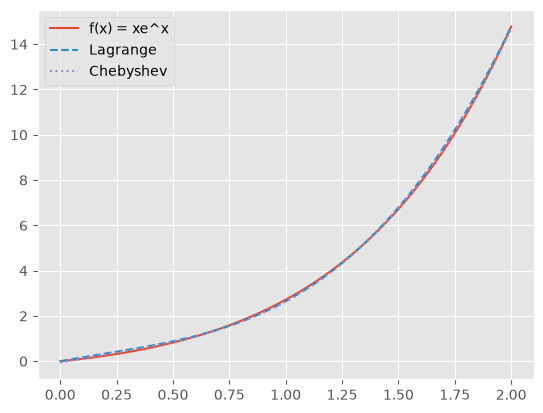

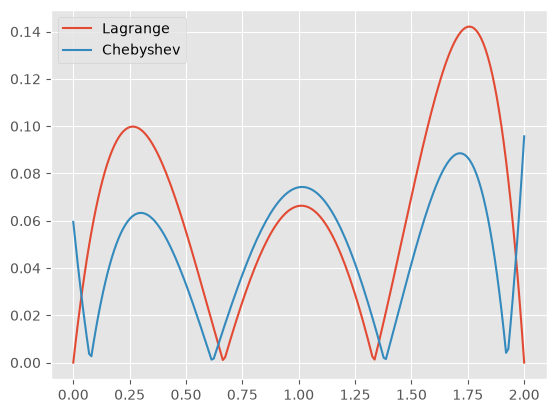

In [3]:
v_ini = 0
v_fin = 2
num_nodos = 4

f = lambda x: x * np.exp(x)

x_eval = np.linspace(v_ini, v_fin, 200)
y_real = f(x_eval)

# Nodos equiespaciados
x_equ = np.linspace(v_ini, v_fin, num_nodos)
y_equ = f(x_equ)
p_equ = Lagrange_poli(x_equ, y_equ, x_eval)

# Nodos de Chebyshev
k = np.arange(num_nodos)
x_k = np.cos((2*k + 1)/(2*num_nodos) * np.pi)

# Transformacion lineal de [-1, 1] al intervalo [v_ini, v_fin]
x_cheb = map(x_k, -1, 1, v_ini, v_fin)

print(x_k.min())
print(x_k.max())
print(x_cheb.min())
print(x_cheb.max())

y_cheb = f(x_cheb)
p_cheb = Lagrange_poli(x_cheb, y_cheb, x_eval)

plt.figure()
plt.plot(x_eval, y_real, label='f(x) = xe^x')
plt.plot(x_eval, p_equ, '--', label='Lagrange')
plt.plot(x_eval, p_cheb, ':', label='Chebyshev')
plt.legend()
plt.grid(True)

err_lag = np.abs(y_real - p_equ)
err_cheb = np.abs(y_real - p_cheb)

plt.figure()
plt.plot(x_eval, err_lag, label='Lagrange')
plt.plot(x_eval, err_cheb, label='Chebyshev')
plt.legend()
plt.show()